In [2]:
"""
MAE 6760 Model Based Estimation
Cornell University
M Campbell

Homework #3
Problem #2: Kalman Filter
    Two aircraft tracking estimator in 2D as they turn
    uses the following Python functions:
        plot_openloop.py
        plot_estimator.py
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import cont2discrete
from scipy.stats import chi2
from scipy.linalg import sqrtm, block_diag

from plot_estimator import plot_estimator

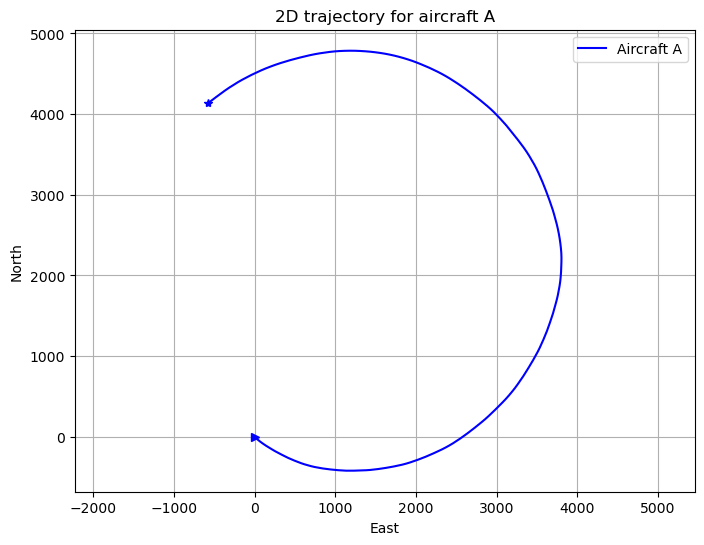

In [29]:
np.random.seed(101)

# ============================================================
# 2D Aircraft Open Loop Plot
# ============================================================

def plot_openloop_2D_aircraft(x_A, x_B=None):

    plt.figure(figsize=(8,6))

    plt.plot(x_A[0,:], x_A[2,:], 'b-')
    plt.plot(x_A[0,0], x_A[2,0], 'b>')
    plt.plot(x_A[0,-1], x_A[2,-1], marker='*', color='b')

    if x_B is not None:
        plt.plot(x_B[0,:], x_B[2,:], 'r:')
        plt.plot(x_B[0,0], x_B[2,0], 'r>')
        plt.plot(x_B[0,-1], x_B[2,-1], marker='*', color='r')
        plt.legend(["Aircraft A","Aircraft B"])
    else:
        plt.legend(["Aircraft A"])

    plt.xlabel("East")
    plt.ylabel("North")
    plt.grid(True)


# ============================================================
# Aircraft A Model
# ============================================================

# continuous time model for aircraft A
Omega_A = 0.045
nx = 4
A_A = np.array([[0,1,0,0],
                [0,0,0,-Omega_A],
                [0,0,0,1],
                [0,Omega_A,0,0]])

B_A = np.array([[0,0],[1,0],[0,0],[0,1]])
H_A = np.array([[1,0,0,0],
                [0,0,1,0]])

# discrete time model for aircraft A
dt = 0.5
F_A, G_A, _, _, _ = cont2discrete((A_A,B_A,np.eye(4),0), dt)

Q_A = 10*np.array([[2.0,0.05],[0.05,0.5]])
R_A = np.array([[20,0.05],[0.05,20]])

tvec = np.arange(0,100+dt,dt)
nk = len(tvec)

x0_A = np.array([0,85*np.cos(np.pi/4),0,-85*np.sin(np.pi/4)])

# simulate aircraft A
w_A = sqrtm(Q_A) @ np.random.randn(2,nk)
x_A = np.zeros((4,nk))
x_A[:,0] = x0_A

for k in range(nk-1):
    x_A[:,k+1] = F_A @ x_A[:,k] + G_A @ w_A[:,k]

z_A = H_A @ x_A + sqrtm(R_A) @ np.random.randn(2,nk)

plot_openloop_2D_aircraft(x_A)
plt.title("2D trajectory for aircraft A")
plt.axis("equal")
plt.show()

In [30]:
F_D = np.array([[1,np.sin(Omega_A*dt), 0 , -((1-np.cos(Omega_A*dt))/Omega_A)],
                [0, np.cos(Omega_A*dt), 0, -np.sin(Omega_A*dt)],
                [0, (1-np.cos(Omega_A*dt))/Omega_A, 1, np.sin(Omega_A*dt)/Omega_A],
                [0, np.sin(Omega_A*dt), 0, np.cos(Omega_A*dt)]])
print(F_D)

[[ 1.          0.0224981   0.         -0.00562476]
 [ 0.          0.99974689  0.         -0.0224981 ]
 [ 0.          0.00562476  1.          0.49995781]
 [ 0.          0.0224981   0.          0.99974689]]


In [31]:
# ============================================================
# (a) Baseline Kalman Filter
# ============================================================
# goal: KF to track/localize aircraft A
# 
# use model for aircraft A for this problem
# use measurements z_A for this problem
# 

## YOUR CODE HERE

#initialize
xhatk_k = x0_A
Pk_k = 100 * np.eye(nx)

#preallocate
xhatu = np.zeros((nx,nk))
Pu = np.zeros((nx,nx,nk))
GQGT = G_A@Q_A@G_A.T
I =np.identity(nx)


for i in range(nk):
    xhatu[:,i] = xhatk_k
    Pu[:,:,i] = Pk_k

    

    #predict
    xhatk1_k = F_A@xhatk_k
    Pk1_k = F_A@Pk_k@ F_A.T + GQGT

    #Kalman Gain
    Kk1 = Pk1_k@H_A.T @ np.linalg.inv(H_A@Pk1_k@H_A.T + R_A)

    #update
    xhatk1_k1 = xhatk1_k + Kk1@(z_A[:, i] - H_A@xhatk1_k)
    Pk1_k1 = (I - Kk1@H_A)@Pk1_k@(I - Kk1@H_A).T + Kk1@R_A@Kk1.T

    # relabel to iterate
    Pk_k = Pk1_k1
    xhatk_k = xhatk1_k1

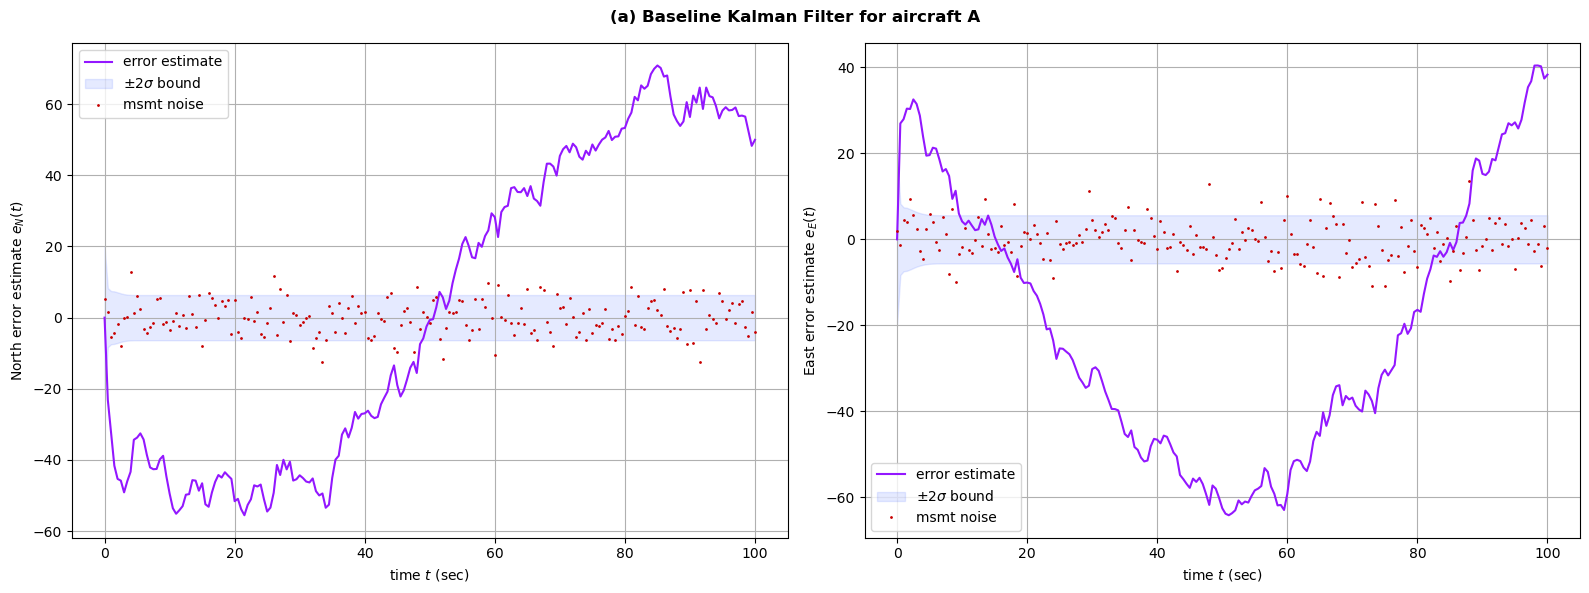

In [32]:
fig, axs = plt.subplots(1,2,figsize=(16,6))
plot_estimator(tvec,xhatu[0,:],Pu[0,0,:],x_A[0,:],plot_type='error',z=z_A[0,:],ax=axs[0])
axs[0].set_ylabel("North error estimate $e_N(t)$")
plot_estimator(tvec,xhatu[2,:],Pu[2,2,:],x_A[2,:],plot_type='error',z=z_A[1,:],ax=axs[1])
axs[1].set_ylabel("East error estimate $e_E(t)$")
plt.suptitle("(a) Baseline Kalman Filter for aircraft A", fontweight='bold')
plt.tight_layout()


In [ ]:
# ============================================================
# (b) 95% Measurement Gating
# ============================================================
# goal: KF to track/localize aircraft A with measurement gate
# 
# use model for aircraft A for this problem
# use measurements z_A for this problem
# 
# variables to generate for display/plots:
#  Nrej: number of measurement rejections (subset of total nk)
#  Trej: times tvec[k+1] when msmt is rejected 
#  Erej: error z[:,k+1]-H*x_A(:,k+1] when msmt is rejected

# msmt gating parameters
Lam0 = chi2.ppf(0.95,2)
Lam = np.zeros(nk)

Nrej = 0
Irej = []

## YOUR CODE HERE

# uncomment lines below to output the percent of msmts rejected
# print("(b) percent msmts rejected:",Nrej/nk*100)

fig, axs = plt.subplots(1,2,figsize=(16,6))

plot_estimator(tvec,xhatu[0,:],Pu[0,0,:],x_A[0,:],plot_type='error',z=z_A[0,:],ax=axs[0])
# uncomment the line below to add msmt rejections to the plot
# axs[0].plot(Trej, Erej[0,:], 'mo', fillstyle='none', label='Msmt Rejection')
axs[0].set_ylabel("North error estimate $e_N(t)$")
axs[0].legend()

plot_estimator(tvec,xhatu[2,:],Pu[2,2,:],x_A[2,:],plot_type='error',z=z_A[1,:],ax=axs[1])
# uncomment the line below to add msmt rejections to the plot
# axs[1].plot(Trej, Erej[1,:], 'mo', fillstyle='none', label='Msmt Rejection')
axs[1].set_ylabel("East error estimate $e_E(t)$")
axs[1].legend()
plt.suptitle("(b) Kalman Filter with 95% msmt gating for aircraft A", fontweight='bold')
plt.tight_layout()




In [ ]:
# ============================================================
# (c) Process Noise Tuning + Filter Integrity
# ============================================================
# goal: use hypothesis tests to tune process noise covariance Q 
# 
# use model for aircraft A for this problem
# load simulated measurements from tile (these are for aircraft A, but labeled z_c for Part c
# use measurements z_c for this problem
# use states x_c for the plots on problem
# 
# variables to generate for display/plots:
#  Lam: innovations test statistic lambda (1 x nk)
#  LamF: Kalman Filter test statistic lambda (1 x nk)
#  Nrej: number of measurement rejections (subset of total nk)
#  Trej: times tvec[k+1] when msmt is rejected 
#  Erej: error z[:,k+1]-H*x_c[:,k+1] when msmt is rejected
#  NFrej: number of times the filter is inconsistent (subset of total nk)
#  TFrej: times tvec[k+1] when the filter is inconsistent 
#  EFrej: error z[:,k+1]-H*x_c[:,k+1] when the filter is inconsistent

#load measurement vector z_c and state x_c
data = np.load("ACdata.npz")
z_c = data["z_c"]
x_c = data["x_c"]

Nrej = 0
Irej = []
NFrej = 0
IFrej = []

# msmt gating parameters
Lam0 = chi2.ppf(0.95,2)
Lam = np.zeros(nk)

# filter consistency parameters
Lam = np.zeros(nk)
LamF = np.zeros(nk)
win=10
Blow = chi2.ppf(0.025,10*2)/win
Bhigh = chi2.ppf(0.975,10*2)/win

## YOUR CODE HERE

# uncomment lines below to output the percent of msmts rejected
# print("(c) percent msmts rejected:",Nrej/nk*100)
# print("(c) percent time KF inconsistent:",NFrej/nk*100)

fig, axs = plt.subplots(1,2,figsize=(16,6))

plot_estimator(tvec,xhatu[0,:],Pu[0,0,:],x_c[0,:],plot_type='error',z=z_c[0,:],ax=axs[0])
# uncomment the line below to add msmt rejections to the plot
# axs[0].plot(Trej, Erej[0,:], 'mo', fillstyle='none', label='Msmt Rejection')
axs[0].set_ylabel("North error estimate $e_N(t)$")
axs[0].legend()
plot_estimator(tvec,xhatu[2,:],Pu[2,2,:],x_c[2,:],plot_type='error',z=z_c[1,:],ax=axs[1])
# uncomment the line below to add msmt rejections to the plot
# axs[1].plot(Trej, Erej[1,:], 'mo', fillstyle='none', label='Msmt Rejection')
axs[1].set_ylabel("East error estimate $e_E(t)$")
axs[1].legend()
plt.suptitle("(c): Kalman Filter with Msmt Gate and Filter Integrity for aircraft A", fontweight='bold')
plt.tight_layout()

plt.figure(figsize=(8,6))
plt.plot(tvec,Lam,'m:',label=r'inn test statistic $\lambda$')
plt.plot(tvec[win+1:],LamF[win+1:],'-',color='purple',label=r'KF test statistic $\lambda_{10}^{KF}$')
plt.plot(tvec,Blow*np.ones(nk),'b--',label='lower bound')
plt.plot(tvec,Bhigh*np.ones(nk),'b--',label='upper bound')
plt.ylabel('filter integrity')
plt.xlabel('time $t$ (sec)')
plt.legend()
plt.title("(c) Kalman Filter integrity test statistic", fontweight='bold')




In [ ]:
# ============================================================
# (d) Joint Kalman Filter (Aircraft A & B)
# ============================================================
# goal: estimate X=[x_A;x_B] given Z=[z_A;z_B]
# 
# use both models for aircraft A and B for this problem
# use measurements Z_A and Z_B for this problem

# continuous time model for aircraft B
Omega_B = -0.045
A_B = np.array([[0,1,0,0],
                [0,0,0,-Omega_B],
                [0,0,0,1],
                [0,Omega_B,0,0]])
B_B = np.array([[0,0],[1,0],[0,0],[0,1]])

# discrete time model for aircraft B
F_B, G_B, _, _, _ = cont2discrete((A_B,B_B,np.eye(nx),0), dt)
Q_B = Q_A
R_B = R_A

# simulate aircraft B
x0_B = np.array([4000,85*np.cos(np.pi/4),3200,-85*np.sin(np.pi/4)])

x_B = np.zeros((4,nk))
x_B[:,0]=x0_B
for k in range(nk-1):
    x_B[:,k+1] = F_B@x_B[:,k] + G_B@w_A[:,k]

z_B = H_A@x_B + sqrtm(R_B)@np.random.randn(2,nk)

plot_openloop_2D_aircraft(x_A,x_B)

## YOUR CODE HERE

fig, axs = plt.subplots(1,2,figsize=(16,6))
plot_estimator(tvec,xhatu[0,:],Pu[0,0,:],x_A[0,:],plot_type='error',z=z_A[0,:],ax=axs[0])
axs[0].set_ylabel("North error estimate $e_N(t)$")
axs[0].legend()
plot_estimator(tvec,xhatu[2,:],Pu[2,2,:],x_A[2,:],plot_type='error',z=z_A[1,:],ax=axs[1])
axs[1].set_ylabel("East error estimate $e_E(t)$")
axs[1].legend()
plt.suptitle("(d): Joint Kalman Filter: aircraft A errors", fontweight='bold')
plt.tight_layout()

fig, axs = plt.subplots(1,2,figsize=(16,6))
plot_estimator(tvec,xhatu[nx+0,:],Pu[nx+0,nx+0,:],x_B[0,:],plot_type='error',z=z_B[0,:],ax=axs[0])
axs[0].set_ylabel("North error estimate $e_N(t)$")
axs[0].legend()
plot_estimator(tvec,xhatu[nx+2,:],Pu[nx+2,nx+2,:],x_B[2,:],plot_type='error',z=z_B[1,:],ax=axs[1])
axs[1].set_ylabel("East error estimate $e_E(t)$")
axs[1].legend()
plt.suptitle("(d): Joint Kalman Filter: aircraft B errors", fontweight='bold')
plt.tight_layout()

In [ ]:
# ============================================================
# (e) Joint Kalman Filter with Relative Range Sensor
# ============================================================
# goal: estimate X=[X_A;X_B] given Z=[z_A;z_B]
#       --> repeat (d), but for a 2D range measurement
# 
# use both models for aircraft A and B for this problem
# use measurements Zr for this problem

Rr = np.array([[10,0.15],[0.15,10]])
Hr = np.array([[1,0,0,0,-1,0,0,0],
               [0,0,1,0,0,0,-1,0]])

Zr = np.vstack((x_A[0,:]-x_B[0,:],
                x_A[2,:]-x_B[2,:])) + sqrtm(Rr)@np.random.randn(2,nk)


## YOUR CODE HERE


fig, axs = plt.subplots(1,2,figsize=(16,6))
plot_estimator(tvec,xhatu[0,:],Pu[0,0,:],x_A[0,:],plot_type='error',z=z_A[0,:],ax=axs[0])
axs[0].set_ylabel("North error estimate $e_N(t)$")
axs[0].legend()
plot_estimator(tvec,xhatu[2,:],Pu[2,2,:],x_A[2,:],plot_type='error',z=z_A[1,:],ax=axs[1])
axs[1].set_ylabel("East error estimate $e_E(t)$")
axs[1].legend()
plt.suptitle("(e): Joint KF with Relative Range: aircraft A errors", fontweight='bold')
plt.tight_layout()

fig, axs = plt.subplots(1,2,figsize=(16,6))
plot_estimator(tvec,xhatu[nx+0,:],Pu[nx+0,nx+0,:],x_B[0,:],plot_type='error',z=z_B[0,:],ax=axs[0])
axs[0].set_ylabel("North error estimate $e_N(t)$")
axs[0].legend()
plot_estimator(tvec,xhatu[nx+2,:],Pu[nx+2,nx+2,:],x_B[2,:],plot_type='error',z=z_B[1,:],ax=axs[1])
axs[1].set_ylabel("East error estimate $e_E(t)$")
axs[1].legend()
plt.suptitle("(e): Joint KF with Relative Range: aircraft B errors", fontweight='bold')
plt.tight_layout()

plt.show()